In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

In [2]:
df = pd.read_csv('Merged_SoilMoisture_Data.csv')

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Points: {df['Point_ID'].nunique()}  |  Dates: {df['Date'].nunique()}")

Loaded: 401 rows × 17 columns
Points: 100  |  Dates: 22


In [11]:
def engineer_features(df):
    df = df.copy()
 
    #  Temporal features (captures seasonal SM cycle) 
    df['month']     = df['Date'].dt.month
    df['doy']       = df['Date'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
 
    #  Fix 3 missing SAR values (spatial median per point) 
    for col in ['VV_500m', 'VH_500m', 'Angle_500m']:
        null_mask = df[col].isnull()
        if null_mask.sum() > 0:
            fill = df.groupby('Point_ID')[col].transform('median')
            df.loc[null_mask, col] = fill[null_mask]
 
    #  SAR physics features 
    df['VV_linear']  = 10 ** (df['VV_500m'] / 10)   # dB → linear
    df['VH_linear']  = 10 ** (df['VH_500m'] / 10)
    df['VV_VH_diff'] = df['VV_500m'] - df['VH_500m']
 
    #  Terrain interaction features 
    df['slope_elev']  = df['Elevation_m'] / (df['Slope'] + 0.1)
    df['rough_slope'] = df['Roughness'] * df['Slope']
 
    df['VV_x_season'] = df['VV_linear'] * df['month_sin']
    df['VH_x_season'] = df['VH_linear'] * df['month_sin']
    df['VV_x_cos']    = df['VV_linear'] * df['month_cos']
    df['VH_x_cos']    = df['VH_linear'] * df['month_cos']
    df['sin_doy'] = np.sin(2*np.pi*df['doy']/365)
    df['cos_doy'] = np.cos(2*np.pi*df['doy']/365)
 
    return df
 
df = engineer_features(df)
 
#FEATURES = [
    # SAR backscatter (raw + linear)
 #   'VV_500m', 'VH_500m', 'Angle_500m',
  #  'VV_linear', 'VH_linear', 'VV_VH_diff',
    # Polarimetric indices
   # 'CR=VH/VV', 'RVI', 'RPI=VV/VH', 'NDPI=(VV-VH)/(VV+VH)', 'MPI',
    # Terrain
   # 'Elevation_m', 'Slope', 'Aspect', 'Roughness',
   # 'slope_elev', 'rough_slope',
    # Temporal
   # 'doy','VV_x_season',
   # 'VH_x_season',
   # 'VV_x_cos',   
   # 'VH_x_cos','month_sin', 'month_cos' ]   
 
    

 
#X = df[FEATURES].copy()
#y = df['Observed_SM'].copy()

In [12]:
!pip install optuna

In [13]:
import numpy as np
import pandas as pd
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBRegressor, callback
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# FEATURES

FEATURES = [
    'VV_500m', 'VH_500m', 'Angle_500m',
    'VV_linear', 'VH_linear', 'VV_VH_diff',
    'CR=VH/VV', 'RVI', 'RPI=VV/VH', 'NDPI=(VV-VH)/(VV+VH)', 'MPI',
    'Elevation_m', 'Slope', 'Aspect', 'Roughness',
    'slope_elev', 'rough_slope',
    
    'doy', 'VV_x_season', 'VH_x_season', 'VV_x_cos', 'VH_x_cos','sin_doy','cos_doy'
]

X = df[FEATURES].copy()
y = df['Observed_SM'].copy()


# TRAIN / TEST SPLIT

np.random.seed(42)
test_pts   = np.random.choice(df['Point_ID'].unique(), size=20, replace=False)
train_mask = ~df['Point_ID'].isin(test_pts)
test_mask  =  df['Point_ID'].isin(test_pts)

X_train = X[train_mask].values
X_test  = X[test_mask].values
y_train = y[train_mask].values
y_test  = y[test_mask].values

scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

gkf          = GroupKFold(n_splits=5)
groups       = df['Point_ID'].values
groups_train = df.loc[train_mask, 'Point_ID'].values


# METRICS

def full_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    r    = np.corrcoef(y_true, y_pred)[0, 1]
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    print(f"  R²   : {r2:.4f}")
    print(f"  R    : {r:.4f}")
    print(f"  RMSE : {rmse:.4f} m³/m³")
    print(f"  MAE  : {mae:.4f} m³/m³")
    print(f"  Bias : {bias:.4f} m³/m³")
    return dict(r2=r2, r=r, rmse=rmse, mae=mae, bias=bias)


# OPTUNA — XGBoost


print("Tuning XGBoost with Optuna...")

def xgb_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 1000),
        max_depth        = trial.suggest_int('max_depth', 3, 6),
        learning_rate    = trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 10.0),
        objective        = 'reg:squarederror',
        tree_method      = 'hist',
        random_state     = 42,
        n_jobs           = -1,
    )

    fold_scores = []
    for tr_idx, val_idx in gkf.split(X, y, groups):
        X_tr  = X.iloc[tr_idx].values
        X_val = X.iloc[val_idx].values
        y_tr  = y.iloc[tr_idx].values
        y_val = y.iloc[val_idx].values

        sc       = RobustScaler()
        X_tr_sc  = sc.fit_transform(X_tr)
        X_val_sc = sc.transform(X_val)

        model = XGBRegressor(**params)
        model.fit(X_tr_sc, y_tr, verbose=False)

        fold_scores.append(r2_score(y_val, model.predict(X_val_sc)))

    return np.mean(fold_scores)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nXGB best CV R² : {study.best_value:.4f}")
print(f"XGB best params: {study.best_params}")


# OPTUNA — ExtraTrees

print("\nTuning ExtraTrees with Optuna...")

def et_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 15),
        max_features     = trial.suggest_float('max_features', 0.3, 1.0),
    )

    fold_scores = []
    for tr_idx, val_idx in gkf.split(X, y, groups):
        X_tr  = X.iloc[tr_idx].values
        X_val = X.iloc[val_idx].values
        y_tr  = y.iloc[tr_idx].values
        y_val = y.iloc[val_idx].values

        sc       = RobustScaler()
        X_tr_sc  = sc.fit_transform(X_tr)
        X_val_sc = sc.transform(X_val)

        model = ExtraTreesRegressor(**params, random_state=42, n_jobs=-1)
        model.fit(X_tr_sc, y_tr)

        fold_scores.append(r2_score(y_val, model.predict(X_val_sc)))

    return np.mean(fold_scores)

study_et = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_et.optimize(et_objective, n_trials=50, show_progress_bar=True)

print(f"\nET  best CV R² : {study_et.best_value:.4f}")
print(f"ET  best params: {study_et.best_params}")


# TRAIN FINAL MODELS

best_xgb_params = study.best_params.copy()
best_xgb_params.update(dict(
    objective    = 'reg:squarederror',
    tree_method  = 'hist',
    random_state = 42,
    n_jobs       = -1,
))

best_xgb = XGBRegressor(**best_xgb_params)
best_et  = ExtraTreesRegressor(**study_et.best_params, random_state=42, n_jobs=-1)

best_xgb.fit(X_train_sc, y_train, verbose=False)
best_et.fit(X_train_sc, y_train)


# TUNE ENSEMBLE WEIGHTS


_, val_idx = list(gkf.split(X_train_sc, y_train, groups=groups_train))[0]

xgb_val = best_xgb.predict(X_train_sc[val_idx])
et_val  = best_et.predict(X_train_sc[val_idx])
y_val   = y_train[val_idx]

best_r2, best_w = -999, 0.5
for w in np.arange(0.1, 0.95, 0.05):
    r2 = r2_score(y_val, w * xgb_val + (1 - w) * et_val)
    if r2 > best_r2:
        best_r2, best_w = r2, w

wx = round(best_w, 2)
we = round(1 - wx, 2)
print(f"\nBest ensemble weights — XGB: {wx}  ET: {we}")


# EVALUATE

train_pred = wx * best_xgb.predict(X_train_sc) + we * best_et.predict(X_train_sc)
test_pred  = wx * best_xgb.predict(X_test_sc)  + we * best_et.predict(X_test_sc)

train_m = full_metrics(y_train, train_pred, "TRAIN")
test_m  = full_metrics(y_test,  test_pred,  "TEST (spatial holdout)")


# 5-FOLD SPATIAL CV

print(f"\n{'─'*40}")
print(f"  5-FOLD SPATIAL CV")
print(f"{'─'*40}")

fold_r2, fold_rmse, fold_mae = [], [], []

for fold, (tr_idx, val_idx) in enumerate(
        gkf.split(X, y, groups=groups), 1):

    X_tr  = X.iloc[tr_idx].values
    X_val = X.iloc[val_idx].values
    y_tr  = y.iloc[tr_idx].values
    y_val = y.iloc[val_idx].values

    sc       = RobustScaler()
    X_tr_sc  = sc.fit_transform(X_tr)
    X_val_sc = sc.transform(X_val)

    m_xgb = XGBRegressor(**best_xgb_params)
    m_et  = ExtraTreesRegressor(**study_et.best_params, random_state=42, n_jobs=-1)

    m_xgb.fit(X_tr_sc, y_tr, verbose=False)
    m_et.fit(X_tr_sc, y_tr)

    val_pred = wx * m_xgb.predict(X_val_sc) + we * m_et.predict(X_val_sc)

    f_r2   = r2_score(y_val, val_pred)
    f_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    f_mae  = mean_absolute_error(y_val, val_pred)

    fold_r2.append(f_r2)
    fold_rmse.append(f_rmse)
    fold_mae.append(f_mae)

    print(f"  Fold {fold}  →  R²={f_r2:.4f}  RMSE={f_rmse:.4f}  MAE={f_mae:.4f}")

print(f"{'─'*40}")
print(f"  Mean  →  R²={np.mean(fold_r2):.4f}  RMSE={np.mean(fold_rmse):.4f}  MAE={np.mean(fold_mae):.4f}")
print(f"  Std   →  R²={np.std(fold_r2):.4f}  RMSE={np.std(fold_rmse):.4f}  MAE={np.std(fold_mae):.4f}")


# FEATURE IMPORTANCE

xgb_imp = pd.Series(best_xgb.feature_importances_, index=FEATURES)
et_imp  = pd.Series(best_et.feature_importances_,  index=FEATURES)
avg_imp = (wx * xgb_imp + we * et_imp).sort_values(ascending=False)

print("\nTop 10 Feature Importances (weighted avg):")
print(avg_imp.head(10).round(4).to_string())

Tuning XGBoost with Optuna...


  0%|          | 0/100 [00:00<?, ?it/s]


XGB best CV R² : 0.3962
XGB best params: {'n_estimators': 662, 'max_depth': 3, 'learning_rate': 0.01611863975161282, 'subsample': 0.8829874514385198, 'colsample_bytree': 0.5384679124308476, 'min_child_weight': 8, 'gamma': 0.002155402963149423, 'reg_alpha': 0.11103067343447007, 'reg_lambda': 9.755668283282873}

Tuning ExtraTrees with Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]


ET  best CV R² : 0.3969
ET  best params: {'n_estimators': 440, 'max_depth': 10, 'min_samples_leaf': 7, 'max_features': 0.9718937984685726}

Best ensemble weights — XGB: 0.9  ET: 0.1

────────────────────────────────────────
  TRAIN
────────────────────────────────────────
  R²   : 0.7243
  R    : 0.8713
  RMSE : 0.0425 m³/m³
  MAE  : 0.0333 m³/m³
  Bias : -0.0002 m³/m³

────────────────────────────────────────
  TEST (spatial holdout)
────────────────────────────────────────
  R²   : 0.4927
  R    : 0.7084
  RMSE : 0.0605 m³/m³
  MAE  : 0.0459 m³/m³
  Bias : -0.0018 m³/m³

────────────────────────────────────────
  5-FOLD SPATIAL CV
────────────────────────────────────────
  Fold 1  →  R²=0.4533  RMSE=0.0535  MAE=0.0438
  Fold 2  →  R²=0.5845  RMSE=0.0472  MAE=0.0371
  Fold 3  →  R²=0.1584  RMSE=0.0730  MAE=0.0580
  Fold 4  →  R²=0.4080  RMSE=0.0740  MAE=0.0596
  Fold 5  →  R²=0.3968  RMSE=0.0652  MAE=0.0471
────────────────────────────────────────
  Mean  →  R²=0.4002  RMSE=0.0626  M

In [8]:
imp_features=avg_imp.head(10).index.tolist()

Computing SHAP for XGBoost...
Computing SHAP for ExtraTrees...


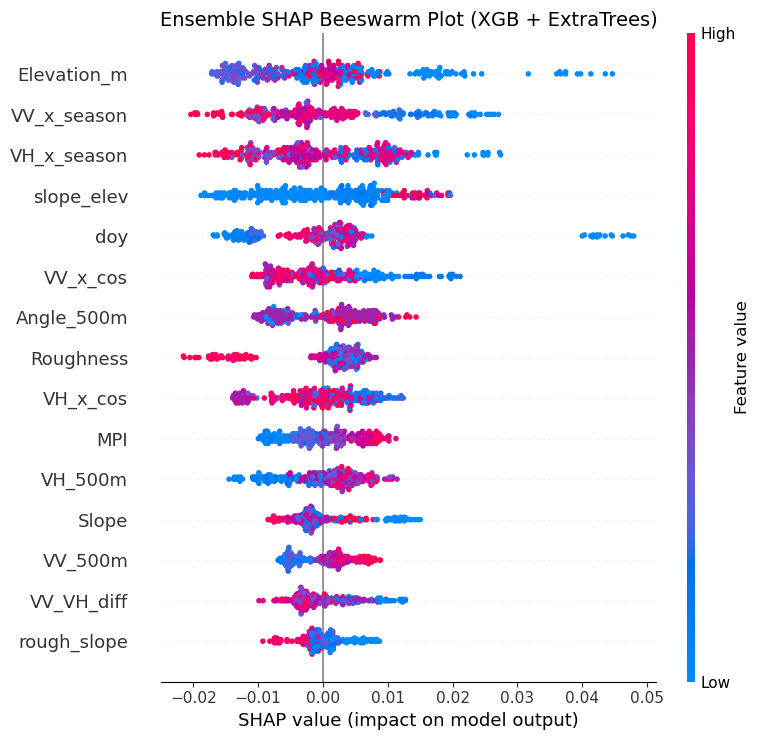

In [16]:
import shap
import numpy as np
import matplotlib.pyplot as plt


# STEP 1 — SHAP FOR XGBOOST

print("Computing SHAP for XGBoost...")

explainer_xgb = shap.TreeExplainer(best_xgb)
shap_xgb = explainer_xgb.shap_values(X_train_sc)


# STEP 2 — SHAP FOR EXTRA TREES
print("Computing SHAP for ExtraTrees...")

explainer_et = shap.TreeExplainer(best_et)
shap_et = explainer_et.shap_values(X_train_sc)


# STEP 3 — ENSEMBLE SHAP (WEIGHTED)

ensemble_shap = (
    wx * shap_xgb +
    we * shap_et
)

# Convert to mean absolute importance
shap_importance = np.abs(ensemble_shap).mean(axis=0)

# Create ranked series
shap_importance = shap_importance / shap_importance.sum()


# STEP 4 — PROFESSIONAL PLOT (CLEAN BARH)

import pandas as pd

imp_series = pd.Series(shap_importance, index=FEATURES)
imp_series = imp_series.sort_values(ascending=True)

plt.figure(figsize=(10, 7))

shap.summary_plot(
    ensemble_shap,
    X_train_sc,
    feature_names=FEATURES,
    max_display=15,
    show=False
)

plt.title("Ensemble SHAP Beeswarm Plot (XGB + ExtraTrees)", fontsize=14)

plt.tight_layout()
plt.show()